# 가설 1-1: 저녁 시간대의 매출은 상주 인구 수에 비례할 것이다

- 분석 기간: 2023년 3분기 ~ 2024년 2분기
- 저녁 시간대: 17시 ~ 24시
- 음식점 업종 코드: CS100001 ~ CS100009 (카페 CS100010 제외)
- 데이터 출처: 서울시 열린 데이터 광장 (http://data.seoul.go.kr/)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 저녁 시간대 매출 데이터 가공 (17~24시)

In [20]:
# 저녁 시간대 매출 분석
df=pd.read_csv("../data/서울시 상권분석서비스(추정매출-자치구).csv",encoding='cp949')
df=df.loc[:,["기준_년분기_코드","자치구_코드","자치구_코드_명","서비스_업종_코드",
             "서비스_업종_코드_명","시간대_17~21_매출_금액","시간대_21~24_매출_금액"]]

# 음식점 업종 구분
df_servicecode=df["서비스_업종_코드"]
df_servicecode_list=df_servicecode.values
df_servicename=df["서비스_업종_코드_명"]
df_servicename_list=df_servicename.values
length=len(df_servicecode_list)
dict_service={}
for idx in range(length):
    dict_service[df_servicecode_list[idx]]=df_servicename_list[idx]
# print(dict_service)
# 내가 구분한 음식점 코드: CS100001-CS100009(CS100010인 카페 제외)

# 분기별 데이터 개수
dict_datanum={}
df_quarter=df["기준_년분기_코드"]
df_quarter_list=df_quarter.values
df_quarter_list=sorted(df_quarter_list)
for quarter in df_quarter_list:
    dict_datanum[quarter]=dict_datanum.get(quarter,0)+1
# print(dict_datanum)

# 2019년 1분기부터 2024년 2분기까지 분기마다 1540개 정도의 데이터로 비슷한 개수를 가진다
# 최근 1년치 데이터 분석(2023년 3분기~2024년 2분기)

In [21]:
# 2023년 3분기
df_20233=df[df.기준_년분기_코드==20233]
df_20233_list=df_20233.values

# 자치구마다 17~21시 매출
dict_20233_sales_17_21={}
for list in df_20233_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20233_sales_17_21[key]=dict_20233_sales_17_21.get(key,0)+value
# print(dict_20233_sales_17_21)

# 자치구마다 21~24시 매출
dict_20233_sales_21_24={}
for list in df_20233_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[6]
    if 100001<=food_code and food_code<=100009:
        dict_20233_sales_21_24[key]=dict_20233_sales_21_24.get(key,0)+value
# print(dict_20233_sales_21_24)

# 17~21 + 21~24
dict_20233_sales_17_24={}
for key in dict_20233_sales_17_21:
    dict_20233_sales_17_24[key]=dict_20233_sales_17_21[key]+dict_20233_sales_21_24[key]
# print(dict_20233_sales_17_24)

In [22]:
# 2023년 4분기
df_20234=df[df.기준_년분기_코드==20234]
df_20234_list=df_20234.values

# 자치구마다 17~21시 매출
dict_20234_sales_17_21={}
for list in df_20234_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20234_sales_17_21[key]=dict_20234_sales_17_21.get(key,0)+value
# print(dict_20234_sales_17_21)

# 자치구마다 21~24시 매출
dict_20234_sales_21_24={}
for list in df_20234_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[6]
    if 100001<=food_code and food_code<=100009:
        dict_20234_sales_21_24[key]=dict_20234_sales_21_24.get(key,0)+value
# print(dict_20234_sales_21_24)

# 17~21 + 21~24
dict_20234_sales_17_24={}
for key in dict_20234_sales_17_21:
    dict_20234_sales_17_24[key]=dict_20234_sales_17_21[key]+dict_20234_sales_21_24[key]
# print(dict_20234_sales_17_24)

In [23]:
# 2024년 1분기
df_20241=df[df.기준_년분기_코드==20241]
df_20241_list=df_20241.values

# 자치구마다 17~21시 매출
dict_20241_sales_17_21={}
for list in df_20241_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20241_sales_17_21[key]=dict_20241_sales_17_21.get(key,0)+value
# print(dict_20241_sales_17_21)

# 자치구마다 21~24시 매출
dict_20241_sales_21_24={}
for list in df_20241_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[6]
    if 100001<=food_code and food_code<=100009:
        dict_20241_sales_21_24[key]=dict_20241_sales_21_24.get(key,0)+value
# print(dict_20241_sales_21_24)

# 17~21 + 21~24
dict_20241_sales_17_24={}
for key in dict_20241_sales_17_21:
    dict_20241_sales_17_24[key]=dict_20241_sales_17_21[key]+dict_20241_sales_21_24[key]
# print(dict_20241_sales_17_24)

In [24]:
# 2024년 2분기
df_20242=df[df.기준_년분기_코드==20242]
df_20242_list=df_20242.values

# 자치구마다 17~21시 매출
dict_20242_sales_17_21={}
for list in df_20242_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[5]
    if 100001<=food_code and food_code<=100009:
        dict_20242_sales_17_21[key]=dict_20242_sales_17_21.get(key,0)+value
# print(dict_20242_sales_17_21)

# 자치구마다 21~24시 매출
dict_20242_sales_21_24={}
for list in df_20242_list:
    key=list[2]
    food_code=int(list[3][2:])
    value=list[6]
    if 100001<=food_code and food_code<=100009:
        dict_20242_sales_21_24[key]=dict_20242_sales_21_24.get(key,0)+value
# print(dict_20242_sales_21_24)

# 17~21 + 21~24
dict_20242_sales_17_24={}
for key in dict_20242_sales_17_21:
    dict_20242_sales_17_24[key]=dict_20242_sales_17_21[key]+dict_20242_sales_21_24[key]
# print(dict_20242_sales_17_24)

## 2. 상주 인구 데이터 가공

In [26]:
# 상주 인구 수 분석
df=pd.read_csv("../data/서울시 상권분석서비스(상주인구-자치구).csv",encoding='cp949')
df=df.loc[:,["기준_년분기_코드","자치구_코드","자치구_코드_명","총_상주인구_수"]]

# 2023년 3분기 상주 인구
df_20233=df[df.기준_년분기_코드==20233]
df_20233_list=df_20233.values
dict_20233_people_living={}
for list in df_20233_list:
    key=list[2]
    value=list[3]
    dict_20233_people_living[key]=value
# print(dict_20233_people_living)

# 2023년 4분기 상주 인구
df_20234=df[df.기준_년분기_코드==20234]
df_20234_list=df_20234.values
dict_20234_people_living={}
for list in df_20234_list:
    key=list[2]
    value=list[3]
    dict_20234_people_living[key]=value
# print(dict_20234_people_living)

# 2024년 1분기 상주 인구
df_20241=df[df.기준_년분기_코드==20241]
df_20241_list=df_20241.values
dict_20241_people_living={}
for list in df_20241_list:
    key=list[2]
    value=list[3]
    dict_20241_people_living[key]=value
# print(dict_20241_people_living)

# 2024년 2분기 상주 인구
df_20242=df[df.기준_년분기_코드==20242]
df_20242_list=df_20242.values
dict_20242_people_living={}
for list in df_20242_list:
    key=list[2]
    value=list[3]
    dict_20242_people_living[key]=value
# print(dict_20242_people_living)

# 분기별로 상주인구는 거의 변화 없음

## 3. 산점도 시각화 및 결과

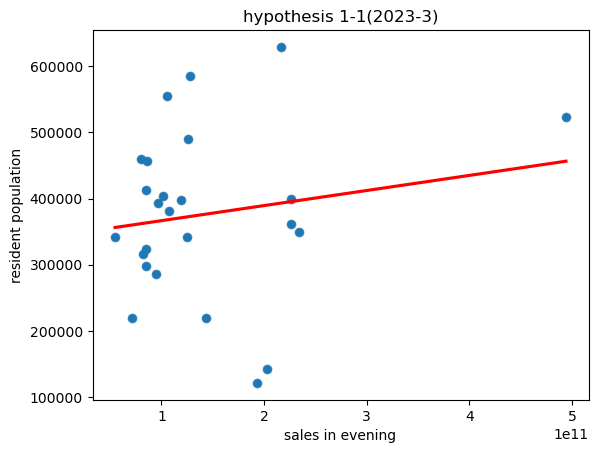

In [28]:
# 2023년 3분기
# [매출, 인구 수] 데이터 리스트
data_20233_11=[]
for key in dict_20233_sales_17_24:
    tempList=[]
    tempList.append(dict_20233_sales_17_24[key])
    tempList.append(dict_20233_people_living[key])
    data_20233_11.append(tempList)
# print(data_20233_11)

# 그래프
df_20233=pd.DataFrame(data_20233_11,columns=["sales in evening","resident population"])
graph=df_20233.plot.scatter(x="sales in evening",y="resident population",title="hypothesis 1-1(2023-3)")
graph=sns.regplot(x="sales in evening",y="resident population",ci=None,data=df_20233,line_kws={"color":"red"})

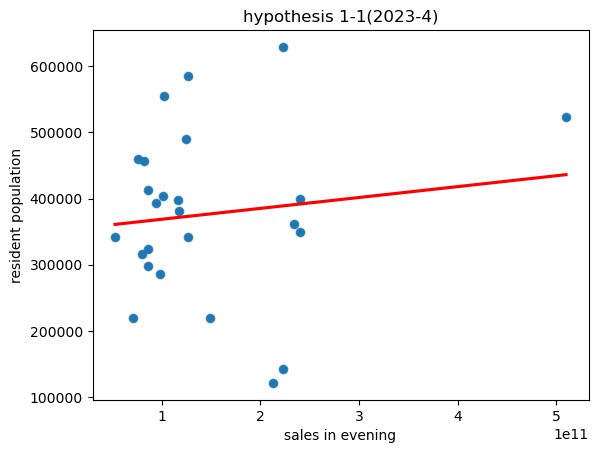

In [29]:
# 2023년 4분기
# [매출, 인구 수] 데이터 리스트
data_20234_11=[]
for key in dict_20234_sales_17_24:
    tempList=[]
    tempList.append(dict_20234_sales_17_24[key])
    tempList.append(dict_20234_people_living[key])
    data_20234_11.append(tempList)
# print(data_20234_11)

# 그래프
df_20234=pd.DataFrame(data_20234_11,columns=["sales in evening","resident population"])
graph=df_20234.plot.scatter(x="sales in evening",y="resident population",title="hypothesis 1-1(2023-4)")
graph=sns.regplot(x="sales in evening",y="resident population",ci=None,data=df_20234,line_kws={"color":"red"})

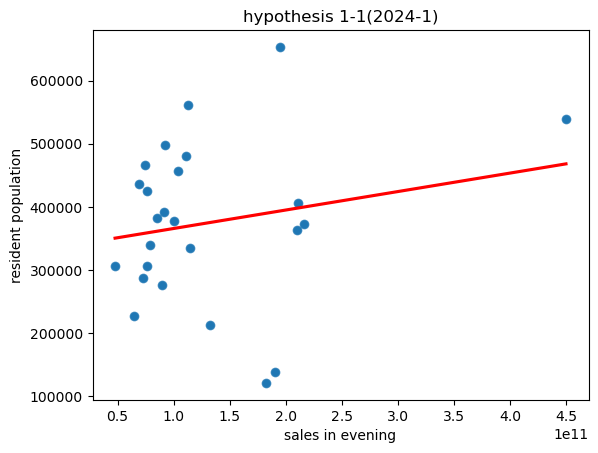

In [30]:
# 2024년 1분기
# [매출, 인구 수] 데이터 리스트
data_20241_11=[]
for key in dict_20241_sales_17_24:
    tempList=[]
    tempList.append(dict_20241_sales_17_24[key])
    tempList.append(dict_20241_people_living[key])
    data_20241_11.append(tempList)
# print(data_20241_11)

# 그래프
df_20241=pd.DataFrame(data_20241_11,columns=["sales in evening","resident population"])
graph=df_20241.plot.scatter(x="sales in evening",y="resident population",title="hypothesis 1-1(2024-1)")
graph=sns.regplot(x="sales in evening",y="resident population",ci=None,data=df_20241,line_kws={"color":"red"})

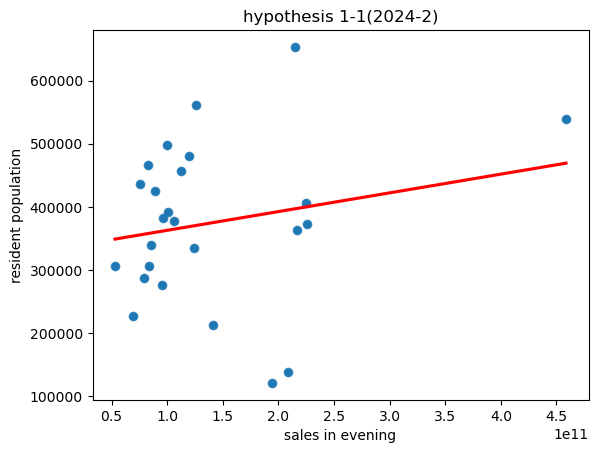

In [31]:
# 2024년 2분기
# [매출, 인구 수] 데이터 리스트
data_20242_11=[]
for key in dict_20242_sales_17_24:
    tempList=[]
    tempList.append(dict_20242_sales_17_24[key])
    tempList.append(dict_20242_people_living[key])
    data_20242_11.append(tempList)
# print(data_20242_11)

# 그래프
df_20242=pd.DataFrame(data_20242_11,columns=["sales in evening","resident population"])
graph=df_20242.plot.scatter(x="sales in evening",y="resident population",title="hypothesis 1-1(2024-2)")
graph=sns.regplot(x="sales in evening",y="resident population",ci=None,data=df_20242,line_kws={"color":"red"})

## 4. 결론

그래프에 그려진 추세선에 데이터들이 몰려있지 않고, 추세선의 기울기가 명확하게 크지 않기 때문에  
**저녁 시간대의 매출과 서울 지역의 상주인구의 상관관계가 없다**고 볼 수 있다.

인구가 많다는 것은 가족 단위의 가구가 많다고도 생각할 수 있고,  
밥을 사먹기 보다는 집에서 해먹으면 음식점의 매출과는 크게 상관이 없을 수 있다.